# [Tutorial](https://github.com/yashizhang/esm/tree/main/cookbook/tutorials): **Using ESMC for zero-shot entropy and position analysis of PETase**

## **Overview**
In this tutorial, we use ESMC to analyze a plastic degrading enzyme called PETase in a zero-shot setting. We use the model to estimate positional constraint and mutation tolerance across the PETase sequence.

PETase is a well-studied bacterial enzyme that naturally degrades polyethylene terephthalate (PET) plastics. Testing mutations that improve enzymatic properties is expensive, but we can use ESMC to prioritize regions of interest for mutation.

## **Learning goals**

After completing this tutorial, you will be able to:


*   Run ESMC inference on a protein sequence
*   Compute per-position entropy as a measure of constraint
*   Compute log-likelihood ratios (LLRs) for all single amino acid substitutions
*   Interpret mutation sensitivity maps for PETase
* Apply this method to any protein of interest!



## **Introduction**

The analysis is based on the idea that if you hide (mask) one amino acid in a protein sequence, a language model trained on proteins can predict which amino acids are likely to belong there.

Let's say you wanted to design a PETase. When generating new variants, either for the purposes of data collection, or for design, you may ask:

  1. At which positions should I mutate the protein? (entropy analysis)

  2. What specific mutations are likely to maintain functional activity? (zero-shot mutational scoring)


We approach **Entropy analysis** by Measuring how strongly the model prefers specific amino acids at each position.


* Low entropy → position is highly constrained
* High entropy → position is mutation-tolerant


To answer which mutations are likely to maintain functional activity, we use **Zero-shot mutation scoring** (LLRs) to compare how likely each possible mutation is relative to the wild-type amino acid.

  *   Positive score → mutation is likely tolerated
  *   Negative score → mutation is likely deleterious








# **1. Setup**

First install and import the necessary dependencies.

In [ ]:
# If you are working in colab, uncomment these lines to install dependencies
# !pip install esm@git+https://github.com/yashizhang/esm.git@main
# !pip install py3dmol

In [ ]:
from getpass import getpass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

%matplotlib inline

from IPython.display import clear_output

from esm.sdk import batch_executor, esmc_client
from esm.sdk.api import ESMProtein, ESMProteinError, LogitsConfig, LogitsOutput
from esm.tokenization import get_esmc_model_tokenizers

clear_output()

In [2]:
# Set up constants

VALID_AMINO_ACIDS = [
    "A",
    "C",
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "K",
    "L",
    "M",
    "N",
    "P",
    "Q",
    "R",
    "S",
    "T",
    "V",
    "W",
    "Y",
]
# Isoelectric points (higher pI ~ more positively charged)
# https://www.vanderbilt.edu/AnS/Chemistry/Rizzo/stuff/AA/AminoAcids.html
AA_TO_ISOELECTRIC_POINT = {
    "A": 6.11,  # Alanine
    "R": 10.76,  # Arginine
    "N": 5.43,  # Asparagine
    "D": 2.98,  # Aspartic Acid
    "C": 5.15,  # Cysteine
    "E": 3.08,  # Glutamic Acid
    "Q": 5.65,  # Glutamine
    "G": 6.06,  # Glycine
    "H": 7.64,  # Histidine
    "I": 6.04,  # Isoleucine
    "L": 6.04,  # Leucine
    "K": 9.47,  # Lysine
    "M": 5.71,  # Methionine
    "F": 5.76,  # Phenylalanine
    "P": 6.30,  # Proline
    "S": 5.70,  # Serine
    "T": 5.60,  # Threonine
    "W": 5.88,  # Tryptophan
    "Y": 5.63,  # Tyrosine
    "V": 6.02,  # Valine
}

# **2. Set up ESMC client**
First, we need to set up the Biohub client. Generate an API key on the [Biohub platform](https://biohub.ai) and add it to your account. This API key manages your access to credits and tokens, and the term API key/token is often used interchangeably within documentation.

Please note that your API key is like a password for your account and you should take care to protect it. For this reason it is recommended to frequently create a new API key and delete old, unused ones. It is also recommended to paste the API key directly into an environment variable or use a utility like `getpass` as shown in the example below so keys are not accidentally shared or checked into code repositories.

In [ ]:
token = getpass("Token from Biohub console: ")

model_name = "esmc-600m-2024-12"
forge_client = esmc_client(model=model_name, url="https://biohub.ai", token=token)

tokenizer = get_esmc_model_tokenizers()
VOCAB = tokenizer.get_vocab()

# Utility Functions

Below are a couple of utility functions that will be useful to us. We will need the `get_leave_one_out_logits` function later to run masked inference.

In [4]:
def get_logits(client, sequence: str) -> LogitsOutput:
    protein = ESMProtein(sequence=sequence)
    protein_tensor = client.encode(protein)
    if isinstance(protein_tensor, ESMProteinError):
        raise protein_tensor
    return client.logits(protein_tensor, LogitsConfig(sequence=True))


def get_leave_one_out_logits(client, sequence):
    sequences = [sequence[:i] + "_" + sequence[i + 1 :] for i in range(len(sequence))]

    with batch_executor() as executor:
        outputs = executor.execute_batch(
            user_func=get_logits, client=client, sequence=sequences
        )

    return outputs

# **3. Run masked inference on PETase**

Use the `get_leave_one_out_logits` function to perform batched masked inference across all positions in the protein sequence:

1. Replace that amino acid with a mask token
2. Run the model
3. At each masked position, the model outputs a probability distribution over amino acids

In [5]:
capetase_sequence = (
    "AADNPYQRGPDPTNASIEAATGPFAVGTQPIVGASGFGGGQIYYPTDTSQTY"
    "GAVVIVPGFISVWAQLNWLGPRLASQGFVVIGIETSVITDLPDPRGDQALA"
    "ALDWATTRSPVASRIDRTRLAAAGWSMGGGGLRRAALQRPSLKAIVGMAP"
    "WNGERNWSAVTVPTLFFGGSSDAVASPNDHAKPFYNSITRAEKDYIELRNA"
    "DHFFPTSANTTMAKYFISWLKRWVDNDTRYTQFLCPGPSTGLFAPVSASMN"
    "TCPF"
)

In [6]:
logit_outputs = get_leave_one_out_logits(forge_client, capetase_sequence)

Processing  100%|████████████████████████| 259/259 [Elapsed: 00:05 | Remaining: 00:00] , Success=259 Fail=0 Retry=0


# **4. Entropy analysis: how constrained is each position?**

* For each mask at position `i`, compute the entropy of the distribution at that position.
* Low entropy means the postion is more constrained, while high entropy is likely a tolerant to mutation.

Note that because the model appends a `BOS` token at the beginning of the sequence (and `EOS` at the end), we have to add +1 to the index to recover the position we want.



In [7]:
def get_per_position_entropy(logit_outputs, sequence):
    entropies = []
    for i in range(len(sequence)):
        logits = logit_outputs[i].logits.sequence
        position_logits = logits[i + 1]  # +1 for BOS token
        probs = F.softmax(position_logits, dim=-1)
        entropy = -torch.sum(probs * torch.log2(probs + 1e-9)).item()
        entropies.append(entropy)
    return np.array(entropies)


entropies = get_per_position_entropy(logit_outputs, capetase_sequence)

# Plot entropy
Next we plot the entropy at each position of the protein.



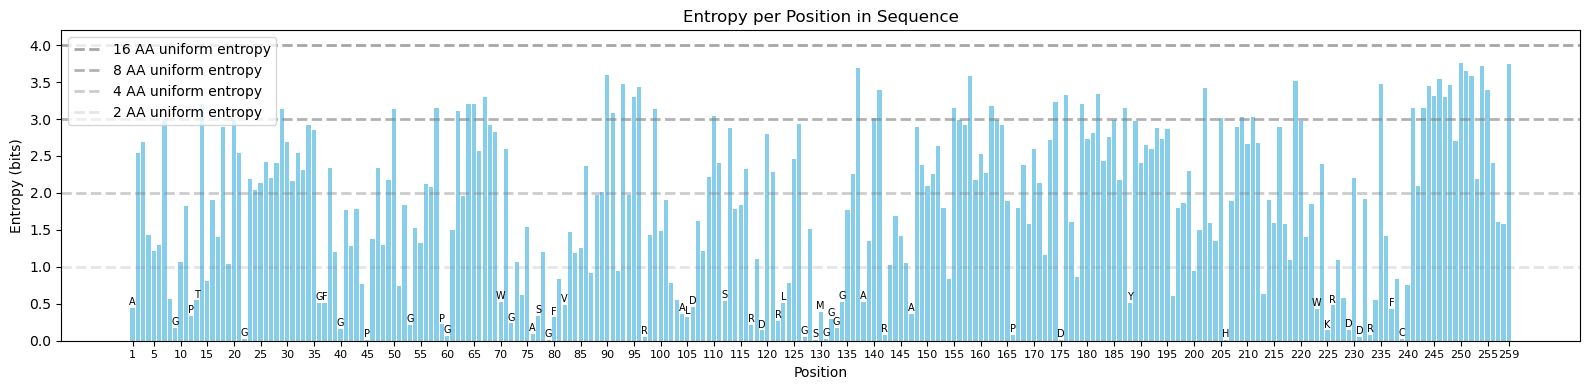

In [8]:
def get_uniform_entropy(n):
    # Compare against a uniform distribution over n amino acids
    probs = torch.tensor([1 / n] * n + [0] * (64 - n))
    return -torch.sum(probs * torch.log2(probs + 1e-9)).item()


def plot_entropy(entropies, sequence):
    entropy_array = np.array(entropies)

    positions = range(len(entropies))
    aa_labels = [aa for aa in sequence]

    plt.figure(figsize=(16, 4))
    plt.bar(positions, entropies, color="skyblue")

    plt.xlabel("Position")
    plt.ylabel("Entropy (bits)")
    plt.title("Entropy per Position in Sequence")

    plt.axhline(
        get_uniform_entropy(16),
        color="grey",
        linestyle="--",
        linewidth=2,
        alpha=0.7,
        label="16 AA uniform entropy",
    )
    plt.axhline(
        get_uniform_entropy(8),
        color="grey",
        linestyle="--",
        linewidth=2,
        alpha=0.6,
        label="8 AA uniform entropy",
    )
    plt.axhline(
        get_uniform_entropy(4),
        color="grey",
        linestyle="--",
        linewidth=2,
        alpha=0.4,
        label="4 AA uniform entropy",
    )
    plt.axhline(
        get_uniform_entropy(2),
        color="grey",
        linestyle="--",
        linewidth=2,
        alpha=0.2,
        label="2 AA uniform entropy",
    )

    plt.legend()

    # x-axis: 1 at left, last position at right, multiples of 5 in between
    L = len(entropies)
    tick_positions = [0] + [i - 1 for i in range(5, L, 5)] + [L - 1]
    tick_labels = [str(i + 1) for i in tick_positions]
    plt.xticks(tick_positions, tick_labels, rotation=0, fontsize=8)

    # Annotate the lowest-entropy (most constrained) positions
    num_lowest = min(50, len(entropies))
    lowest_indices = np.argsort(entropy_array)[:num_lowest]
    for i in lowest_indices:
        plt.text(
            i,
            entropies[i] + 0.01,
            aa_labels[i],
            ha="center",
            va="bottom",
            fontsize=7,
            color="black",
        )

    plt.tight_layout()
    plt.show()


plot_entropy(entropies, capetase_sequence)

**Interpreting the results**
The dashed lines on the plot show what entropy would look like if the model considered multiple amino acids equally likely at a position. The lowest 50 positions are annotated with their wildtype AA.

In [9]:
sorted_idx = np.argsort(entropies)
print("Most constrained (lowest entropy):")
for i in sorted_idx[:5]:
    print(f"{capetase_sequence[i]}{i + 1}: {entropies[i]:.3f}")


print("\nMost tolerant (highest entropy):")
for i in sorted_idx[-5:]:
    print(f"{capetase_sequence[i]}{i + 1}: {entropies[i]:.3f}")

Most constrained (lowest entropy):
H206: 0.007
P45: 0.012
S129: 0.013
G79: 0.014
D175: 0.015

Most tolerant (highest entropy):
S251: 3.646
R137: 3.691
M254: 3.720
F259: 3.749
V250: 3.756


# **5. Zero-shot mutation scores**

At each position, the wildtype AA has LLR = 0.
Other AAs:

* LLR > 0 → model likes it more than WT (more tolerated)

* LLR < 0 → model likes it less than WT (more deleterious)

In [10]:
def get_per_position_log_likelihood_ratios(
    logit_outputs, sequence, vocab=VOCAB
) -> torch.Tensor:
    rows = []
    for i, aa in enumerate(sequence):
        logits = logit_outputs[i].logits.sequence
        logp = torch.log_softmax(logits[i + 1], dim=-1)  # +1 for BOS
        wt_idx = vocab[aa]
        rows.append(logp - logp[wt_idx])
    return torch.stack(rows)

# Plot fraction of deleterious substitutions
While entropy summarizes how constrained a position is overall, it does not tell us how many specific mutations are likely to be deleterious. Here, we quantify mutation tolerance more directly by computing, for each position, the fraction of single–amino acid substitutions whose zero-shot log-likelihood ratio (LLR) is negative relative to the wild type. This provides a simple, interpretable measure of how risky it is to mutate a given position.

In [11]:
def plot_percentage_deleterious_per_position(logit_outputs, sequence, vocab=VOCAB):
    llr = get_per_position_log_likelihood_ratios(logit_outputs, sequence)  # (L, vocab)

    aa_list = VALID_AMINO_ACIDS  # all 20 canonical AAs
    aa_inds = [vocab[a] for a in aa_list]

    llr_20 = llr[:, aa_inds]  # (L, 20)

    # WT has LLR = 0
    percent_negative = (llr_20 < 0).float().mean(dim=1)

    L = len(percent_negative)
    x = np.arange(1, L + 1)

    plt.figure(figsize=(16, 4))
    plt.scatter(x, percent_negative.detach().cpu().numpy(), s=8)
    plt.ylim(0, 1)
    plt.xlabel("Position (1-indexed)")
    plt.ylabel("Fraction deleterious (LLR < 0)")
    plt.title("Fraction of deleterious substitutions per position")

    tick_positions = [1] + list(range(5, L + 1, 5)) + ([L] if L % 5 != 0 else [])
    plt.xticks(tick_positions, [str(p) for p in tick_positions], rotation=0, fontsize=8)

    plt.tight_layout()
    plt.show()

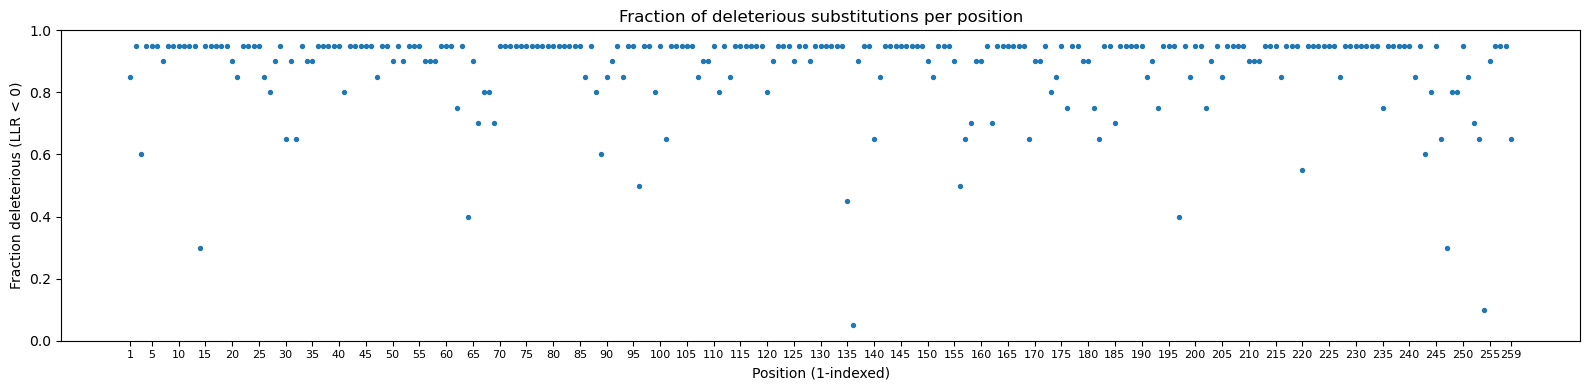

In [12]:
plot_percentage_deleterious_per_position(logit_outputs, capetase_sequence)

**Interpreting the Results**

This plot shows what percentage of mutations are predicted to be harmful at each position.

Most positions in PETase are highly constrained (dots clustered at top), which is typical for functional enzymes. However, we can identify ~10-20 positions with low deleterious fractions — these are mutation-tolerant hotspots.

In [13]:
def get_positions_with_low_deleterious_fraction(
    logit_outputs, sequence, threshold=0.8, vocab=VOCAB
):
    """Select positions where the fraction of deleterious substitutions (LLR < 0) is below the given threshold."""
    log_likelihood_ratios = get_per_position_log_likelihood_ratios(
        logit_outputs, sequence
    )  # shape: (L, vocab)
    aa_list = VALID_AMINO_ACIDS  # all 20 AAs
    aa_inds = [vocab[aa] for aa in aa_list]
    llr_valid = log_likelihood_ratios[:, aa_inds]
    # count the number of negative log likelihood ratios
    negative_llr_count = (llr_valid < 0).sum(dim=1)

    # plot the percentage of negative log likelihood ratios as a scatterplot, one dot per position
    percent_negative = negative_llr_count / llr_valid.shape[1]

    # find positions with percent_negative < threshold
    positions = np.arange(1, len(percent_negative) + 1)  # 1-index the sequence position
    mask = percent_negative < threshold
    low_deleterious_positions = positions[mask]
    low_deleterious_fractions = percent_negative[mask]
    return low_deleterious_positions, low_deleterious_fractions

In [14]:
good_positions, good_fractions = get_positions_with_low_deleterious_fraction(
    logit_outputs, capetase_sequence, threshold=0.8
)

print("Candidate mutation-tolerant positions (1-indexed):")
print(good_positions[:20])

Candidate mutation-tolerant positions (1-indexed):
[  3  14  30  32  62  64  66  69  89  96 101 135 136 140 156 157 158 162
 169 176]


These positions represent mutation-tolerant sites that would be natural candidates for, e.g. random library design.

# Zero-shot LLR heatmap
We can use the LLR heat map to directly predict the effect of every possible single–amino acid substitution across the sequence, enabling targeted selection of substitutions for focused mutagenesis or library design.



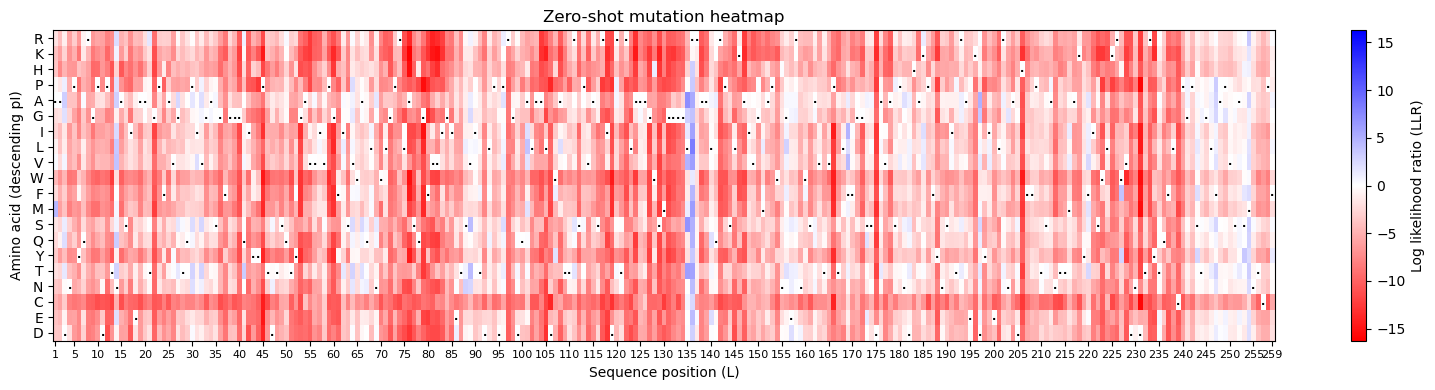

In [15]:
def plot_zero_shot_scores(sequence, logit_outputs, vocab=VOCAB):
    # prepare amino acid ordering by descending pI
    aa_pI_pairs = [(aa, AA_TO_ISOELECTRIC_POINT[aa]) for aa in VALID_AMINO_ACIDS]
    aa_sorted_by_pI = [aa for aa, _ in sorted(aa_pI_pairs, key=lambda x: -x[1])]
    aa_inds = [vocab[aa] for aa in aa_sorted_by_pI]

    # compute LLRs and build image (rows=AA, cols=positions)
    llr = get_per_position_log_likelihood_ratios(
        logit_outputs, sequence, vocab=vocab
    )  # shape: (L, vocab)
    img = llr[:, aa_inds].T.detach().cpu().numpy()  # (20, L)

    vmax = float(np.abs(img).max())
    if vmax == 0 or np.isnan(vmax):
        vmax = 1e-6

    fig, ax = plt.subplots(figsize=(16, 4))
    im = ax.imshow(
        img, aspect="auto", cmap="bwr_r", vmin=-vmax, vmax=vmax, interpolation="nearest"
    )

    # labels
    ax.set_xlabel("Sequence position (L)")
    ax.set_ylabel("Amino acid (descending pI)")

    # y ticks: amino acid labels
    ax.set_yticks(np.arange(len(aa_sorted_by_pI)))
    ax.set_yticklabels(aa_sorted_by_pI)

    # x ticks: 1 at left, multiples of 5 in between, last position at right
    L = img.shape[1]
    tick_positions = [0] + [i - 1 for i in range(5, L, 5)] + [L - 1]
    tick_labels = [str(i + 1) for i in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=0, fontsize=8)

    # mark wildtype residues with a dot
    for pos in range(L):
        wt_aa = sequence[pos]
        if wt_aa in aa_sorted_by_pI:
            wt_idx = aa_sorted_by_pI.index(wt_aa)
            ax.text(
                pos,
                wt_idx,
                ".",
                ha="center",
                va="center",
                color="white" if img[wt_idx, pos] < 0 else "black",
                fontsize=8,
                fontweight="bold",
            )

    fig.colorbar(im, ax=ax, label="Log likelihood ratio (LLR)")
    plt.title("Zero-shot mutation heatmap")

    plt.tight_layout()
    plt.show()


plot_zero_shot_scores(capetase_sequence, logit_outputs)

**Interpreting the results**

This heatmap shows predicted effects of every possible amino acid substitution across the entire PETase sequence.

* Red vertical stripes: Positions where almost all mutations are predicted deleterious (critical positions like the catalytic residues around positions 129, 175, 206).
* Mixed columns with blue/white: Positions where multiple amino acids are tolerated. 
* Horizontal patterns: Some amino acids (like Cysteine, Proline) are rarely tolerated anywhere because they have special structural roles.

This allows you to design focused libraries: Instead of testing all 19 alternatives at each position, you can subset to the top scoring variants.



# **Summary**

In this tutorial, we used ESMC to

* Identify constrained and tolerant positions in PETase via entropy
* Estimate mutation effects using zero‑shot LLRs
* Generate interpretable outputs that can guide protein engineering



# **Next Steps**

What can you do next with these results?

* Use the entropy and deleterious-fraction plots to identify mutation-tolerant positions, and the LLR heatmap to select specific substitutions to prioritize.
* Apply to other proteins. This workflow is sequence-only and requires no multiple sequence alignment or structural information, making it straightforward to apply to other enzymes, binding proteins, or poorly characterized systems.
* Explore additional ESMC tutorials to learn more model uses. 


Limitations

* Zero-shot LLRs reflect the model’s learned sequence preferences, not direct measurements of stability or activity. Predictions should be treated as prioritization signals rather than definitive fitness estimates and are best used in conjunction with experimental validation.